# Exercice 1.2 bis : Visualisations univariées et bivariées — localisation vs prix

Même logique que E2, appliquée à `df_loc` (quartier, zonage, conditions, `SalePrice`).


## Section 1: Imports et configuration


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("AmesHousing.csv")
df.columns = df.columns.str.replace(" ", "")
COLS_LOC = ["Neighborhood", "MSZoning", "Condition1", "Condition2", "SalePrice"]
df_loc = df[COLS_LOC].copy()


## Section 2: Visualisations univariées — variable continue (`SalePrice`)

**À faire :** histogramme, KDE, boxplot vertical du prix.


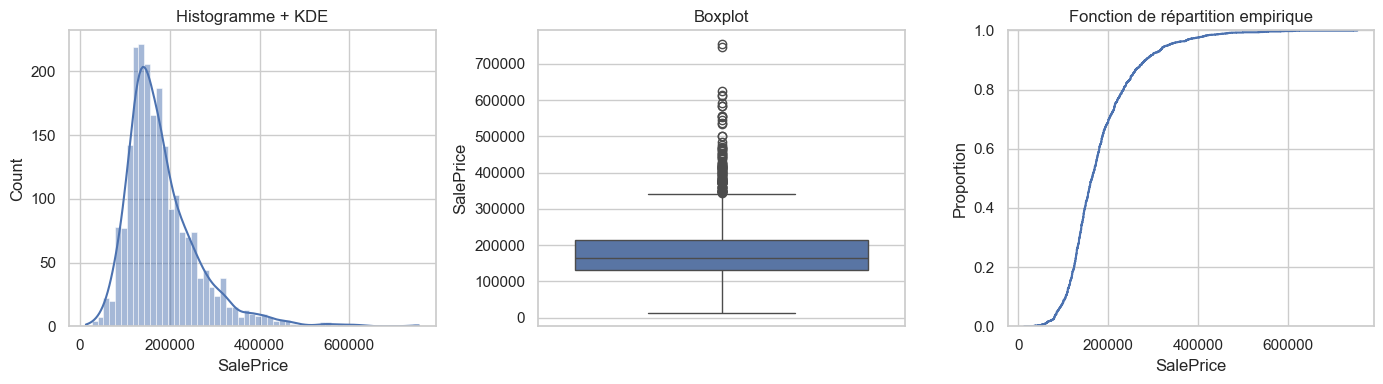

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df_loc["SalePrice"], kde=True, ax=axes[0])
sns.boxplot(y=df_loc["SalePrice"], ax=axes[1])
sns.ecdfplot(df_loc["SalePrice"], ax=axes[2])
axes[0].set_title("Histogramme + KDE")
axes[1].set_title("Boxplot")
axes[2].set_title("Fonction de répartition empirique")
plt.tight_layout()
plt.show()


## Section 3: Visualisations univariées — variables qualitatives de localisation

**À faire :** diagrammes en barres des effectifs pour chaque variable (limiter aux modalités les plus fréquentes si besoin).


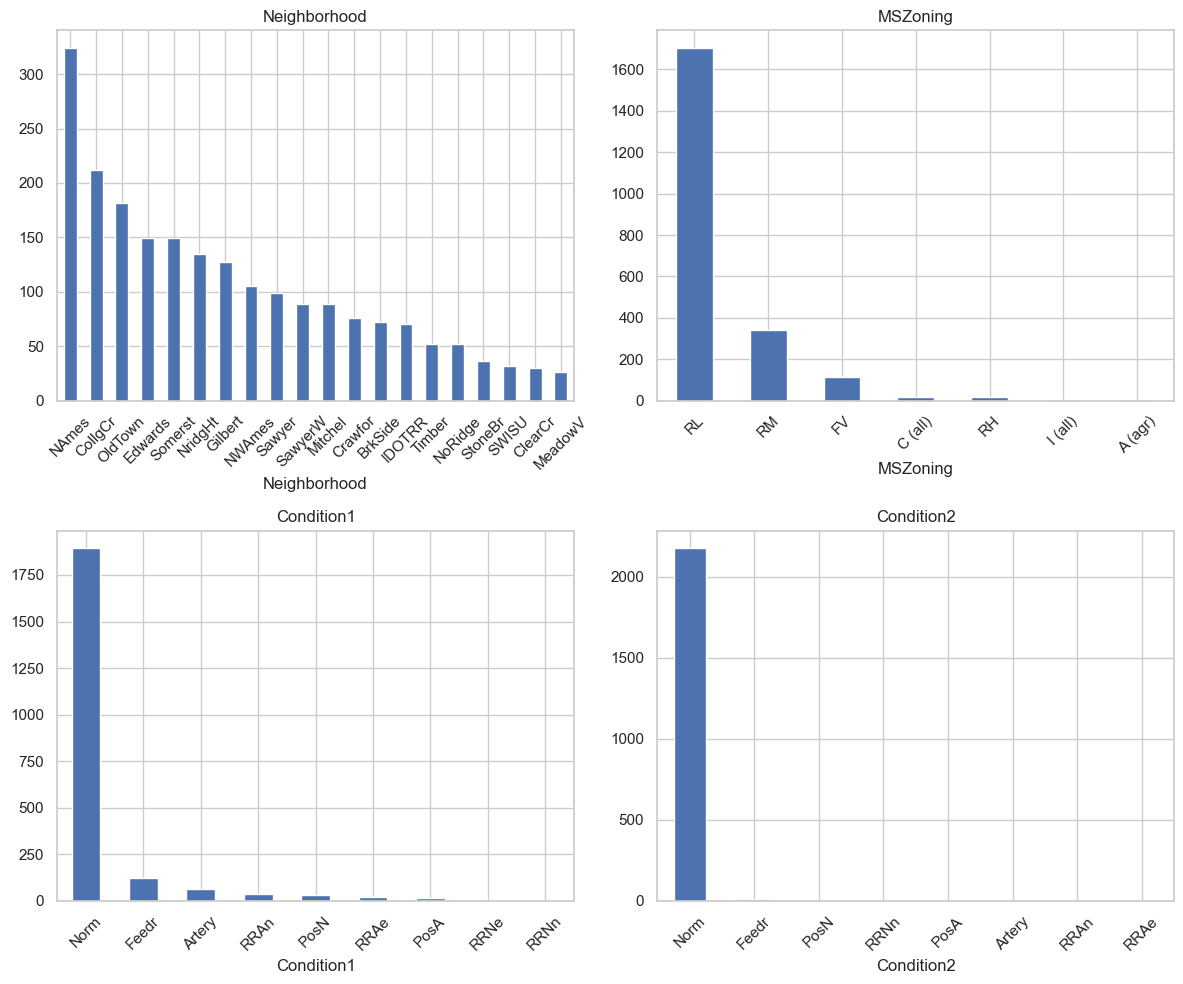

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.ravel(), ["Neighborhood", "MSZoning", "Condition1", "Condition2"]):
    vc = df_loc[col].value_counts().head(20)
    vc.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## Section 4: Visualisations bivariées — prix vs localisation

**À faire :**
- Boxplots ou violin plots de `SalePrice` par `Neighborhood` (rotation des labels).
- Même idée pour `MSZoning`, `Condition1`, `Condition2`.
- Strip plot ou `sns.swarmplot` (échantillon si trop lourd) pour voir la dispersion.


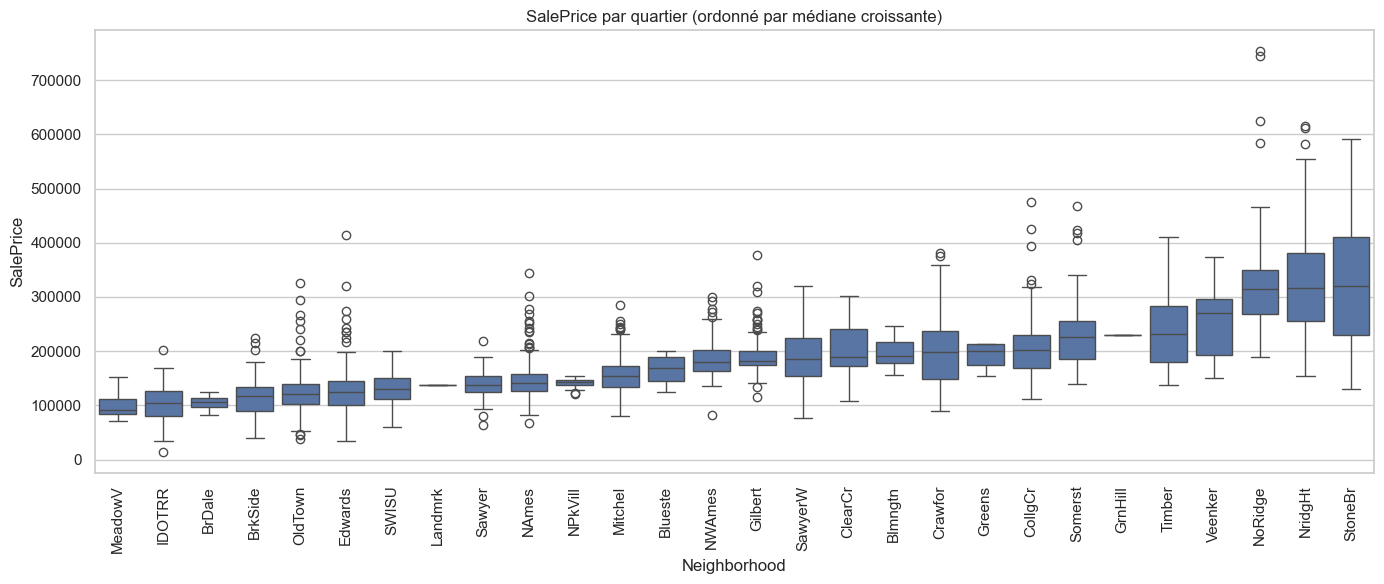

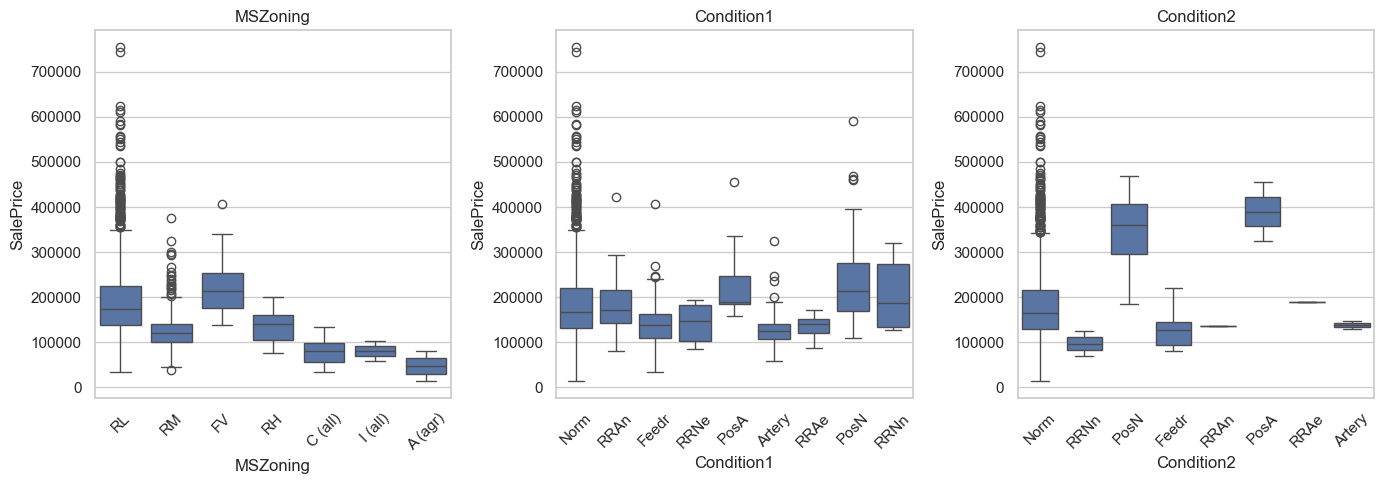

In [4]:
plt.figure(figsize=(14, 6))
order = df_loc.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(data=df_loc, x="Neighborhood", y="SalePrice", order=order)
plt.xticks(rotation=90)
plt.title("SalePrice par quartier (ordonné par médiane croissante)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ["MSZoning", "Condition1", "Condition2"]):
    sns.boxplot(data=df_loc, x=col, y="SalePrice", ax=ax)
    ax.tick_params(axis="x", rotation=45)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## Section 5: Exercice « Bad Viz »

**À faire :** produire **volontairement** un graphique trompeur ou illisible (ex. barres sans échelle log pour des prix très skewés, ou quartiers illisibles sans rotation), puis le corriger dans la cellule suivante avec un court commentaire.


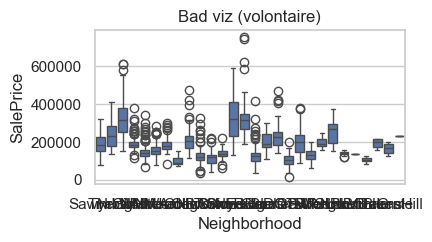

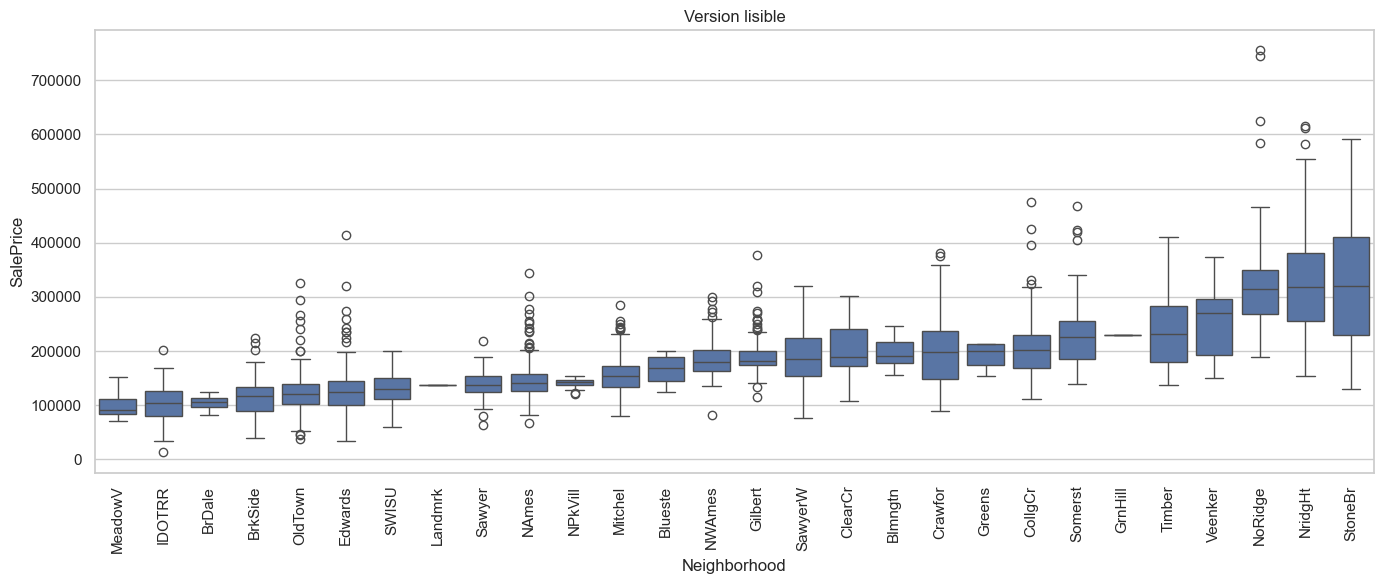

In [5]:
# Mauvais : échelle écrasée, labels illisibles
plt.figure(figsize=(4, 2))
sns.boxplot(data=df_loc, x="Neighborhood", y="SalePrice")
plt.title("Bad viz (volontaire)")
plt.show()

# Corrigé
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_loc, x="Neighborhood", y="SalePrice", order=order)
plt.xticks(rotation=90)
plt.title("Version lisible")
plt.tight_layout()
plt.show()
